In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TIME_OFFSET = 10800 #ADT to UTC is 3hrs

In [50]:
def process_file(input_csv, output_csv):
    print(f"Processing {input_csv}...")

    df = pd.read_csv(input_csv)

    df["timestamp"] = df["frame.time_epoch"] + TIME_OFFSET

    # Sort for IAT calculation
    df = df.sort_values("timestamp")

    df["time_window"] = (df["timestamp"]*10).astype(int) #we basically rounded down all the time-stamps in the granularity of 100mseconds

    packet_counts = df.groupby("time_window").size()
    # print(packet_counts)
    print("description:")
    print(packet_counts.describe())
    # Plot
    plt.figure()
    plt.plot(packet_counts.index - packet_counts.index.min(), packet_counts.values)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Packet Count")
    plt.title("Packets per Second")
    plt.show()

    # inter-arrival time
    df["iat"] = df.groupby(["ip.src", "ip.dst"])["timestamp"].diff().fillna(0) #this basically finds the inter-arrival time for src-dst pairs

    # current granularity is 100ms
    flows = df.groupby(
        ["time_window", "ip.src", "ip.dst"]
    ).agg(
        packet_count=("frame.len", "count"),
        total_bytes=("frame.len", "sum"),
        mean_packet_size=("frame.len", "mean"),
        std_packet_size=("frame.len", "std"),
        iat_mean=("iat", "mean"),
        iat_std=("iat", "std"),
        unique_func_codes=("modbus.func_code", "nunique"),
        exception_count=("modbus.exception_code", lambda x: x.notna().sum())
    ).reset_index()

    flows = flows.fillna(0)

    flows.to_csv(output_csv, index=False)
    print(f"Saved → {output_csv}\n")

Processing ../train/benign_nw.csv...
description:
count    560776.000000
mean          7.049185
std           4.300796
min           1.000000
25%           4.000000
50%           6.000000
75%           9.000000
max          30.000000
dtype: float64


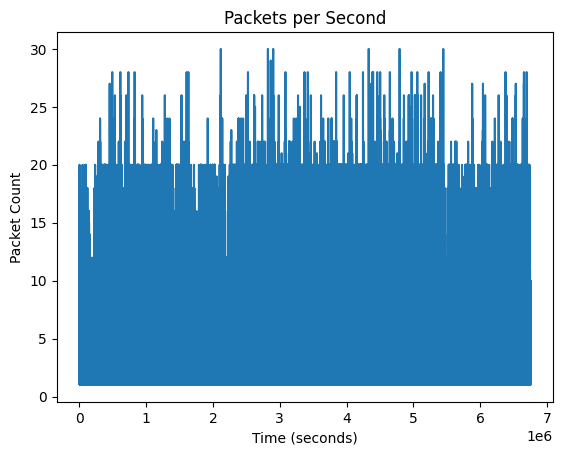

Saved → ../train/benign_flows.csv



In [45]:
process_file("../train/benign_nw.csv", "../train/benign_flows.csv")

Processing ../train/cscada_attack_ssw.csv...
description:
count    628835.000000
mean          5.517533
std          14.012073
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max         670.000000
dtype: float64


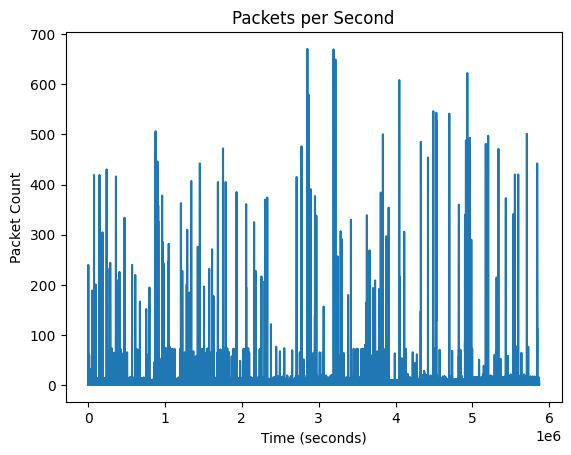

Saved → ../train/cscada_flows.csv



In [51]:
process_file("../train/cscada_attack_ssw.csv", "../train/cscada_flows.csv")

Processing ../train/ext_attack_nw.csv...
description:
count    34264.000000
mean         8.232489
std         17.231504
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max        433.000000
dtype: float64


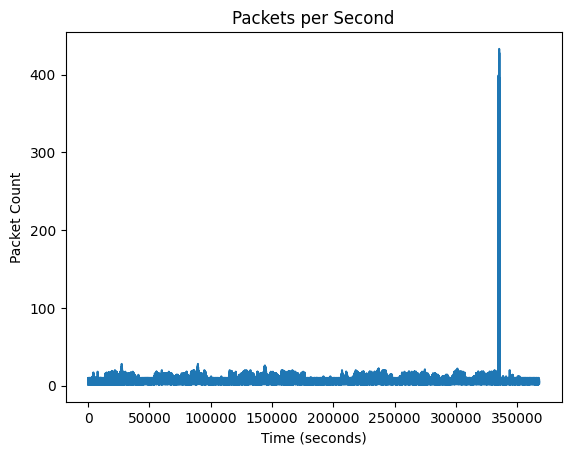

Saved → ../train/external_flows.csv



In [47]:
process_file("../train/ext_attack_nw.csv", "../train/external_flows.csv")